In [1]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import HumanMessage,SystemMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START,END
from tavily import TavilyClient
from typing import TypedDict,Annotated
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import Command, interrupt

In [2]:
load_dotenv()

True

In [3]:
config = {"configurable": {"thread_id": "1"}}


In [4]:
memory = MemorySaver()

In [5]:
llm = init_chat_model(model = "google_genai:gemini-3.6-flash")

In [6]:
@tool
def human_assitance(query: str) -> str:
    """Request assistance from a human when you are uncertain, 
    when information cannot be found on the web, 
    or when performing high-risk actions."""
    human_response = interrupt({"query":query})
    return human_response["data"]

In [7]:
@tool
def web_search(query: str)->dict:
    """search the web for relevant information"""
    client = TavilyClient()
    return client.search(query=query)

In [8]:
tools = [human_assitance,web_search]
binded_llm = llm.bind_tools(tools)

In [9]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [10]:
def llm_with_tools(state: State):
    system = SystemMessage(content="You are a helpful assistant. Use tools when needed but avoid redundant searches. One search should be sufficient for most questions.")
    return {"messages":[binded_llm.invoke([system]+state['messages'])]}

In [11]:
builder = StateGraph(State)

In [12]:
tool_node = ToolNode(tools=tools)

In [13]:
builder.add_node("my_llm", llm_with_tools)
builder.add_node("tools",tool_node)

In [14]:
builder.add_edge(START,"my_llm")
builder.add_conditional_edges(
    "my_llm",tools_condition
)
builder.add_edge("tools","my_llm")
builder.add_edge("tools",END)

In [15]:
graph = builder.compile(checkpointer=memory)

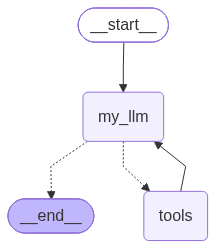

In [16]:
graph

In [17]:
initial_input = {
    "messages": [HumanMessage(content="Can you request human assistance to verify if tomorrow is a holiday?")]
}
# Run the graph
events = graph.invoke(initial_input, config=config)


In [18]:
events

{'messages': [HumanMessage(content='Can you request human assistance to verify if tomorrow is a holiday?', additional_kwargs={}, response_metadata={}, id='5ebaf945-99fb-4c93-8c85-dc769a7441ee'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'human_assitance', 'arguments': '{"query": "Please verify if tomorrow is a holiday. Note: Location context may be needed from the user."}'}, '__gemini_function_call_thought_signatures__': {'call_2286567': 'EtEHCs4HAWkUfROqCvp/WpwqWWRL036eig/bsKqbYI1m4iCmMcz13DA8zarRVND8OFWT8/wSHycIrHxfc8A214AnSuHFxCuDFaL2rODF1EekrZZNM0jzZXAGQr328qLhOv/WAlhzWmprWC80Egfuc/jR9OYE3/TWlWAylVP99wsbla7yclViZNiFlMnM/OwJ/XlJvwFGDbY1vi7Pd5wGbliJ+F47JtH3GEiCyJUJKuCrX/KZxMoeW+DJDYXJVG1bCT2KEYk7jzOQxFygT98qfMxwmVWSmYbQZQoeB1JPTn+ccEFBzQntRs5LL0JQbDG5yywAhPtmkRDwkDaamb7BRX3hVWCNraF6tKH59r6z9C4t+EymcU+w1kDkEVlRiY+V5QEtiNlOi4cSewLrkXOfEXtXZ5ft/d4MwyDirIbFtrtx4B32g9yYJmxG4v3g/0gHQeKURlz90U6L+sthRPZuoAMhZCOpNGJRaOs4QzcFL2eYERAIJ69CPFfwnl1x/MbiyvYV7sFXGIoavfX+/a

In [19]:
state = graph.get_state(config)

print("Next node waiting to run:", state.next)
print("Interrupt query:", state.tasks[0].interrupts[0].value)


Next node waiting to run: ('tools',)
Interrupt query: {'query': 'Please verify if tomorrow is a holiday. Note: Location context may be needed from the user.'}


In [20]:
resume_command = Command(
    resume = {"data":"The holidayas are from dec 28 to jan 3"}
)
final_output = graph.invoke(resume_command,config=config)

In [21]:
final_output

{'messages': [HumanMessage(content='Can you request human assistance to verify if tomorrow is a holiday?', additional_kwargs={}, response_metadata={}, id='5ebaf945-99fb-4c93-8c85-dc769a7441ee'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'human_assitance', 'arguments': '{"query": "Please verify if tomorrow is a holiday. Note: Location context may be needed from the user."}'}, '__gemini_function_call_thought_signatures__': {'call_2286567': 'EtEHCs4HAWkUfROqCvp/WpwqWWRL036eig/bsKqbYI1m4iCmMcz13DA8zarRVND8OFWT8/wSHycIrHxfc8A214AnSuHFxCuDFaL2rODF1EekrZZNM0jzZXAGQr328qLhOv/WAlhzWmprWC80Egfuc/jR9OYE3/TWlWAylVP99wsbla7yclViZNiFlMnM/OwJ/XlJvwFGDbY1vi7Pd5wGbliJ+F47JtH3GEiCyJUJKuCrX/KZxMoeW+DJDYXJVG1bCT2KEYk7jzOQxFygT98qfMxwmVWSmYbQZQoeB1JPTn+ccEFBzQntRs5LL0JQbDG5yywAhPtmkRDwkDaamb7BRX3hVWCNraF6tKH59r6z9C4t+EymcU+w1kDkEVlRiY+V5QEtiNlOi4cSewLrkXOfEXtXZ5ft/d4MwyDirIbFtrtx4B32g9yYJmxG4v3g/0gHQeKURlz90U6L+sthRPZuoAMhZCOpNGJRaOs4QzcFL2eYERAIJ69CPFfwnl1x/MbiyvYV7sFXGIoavfX+/a

In [22]:
for message in final_output["messages"]:
    message.pretty_print()


================================ Human Message =================================

Can you request human assistance to verify if tomorrow is a holiday?
================================== Ai Message ==================================

[]
Tool Calls:
  human_assitance (call_2286567)
 Call ID: call_2286567
  Args:
    query: Please verify if tomorrow is a holiday. Note: Location context may be needed from the user.
================================= Tool Message =================================
Name: human_assitance

The holidayas are from dec 28 to jan 3
================================== Ai Message ==================================

[{'type': 'text', 'text': "I have checked with human assistance. According to the response, the holidays run from **December 28 to January 3**. \n\nWhether tomorrow is a holiday depends on today's date: if today falls between December 27 and January 2, then tomorrow falls within the holiday period.", 'extras': {'signature': 'EvMBCvABAWkUfRPtVmQ5K1tSboFBHDCJ7

In [23]:
graph.invoke({"messages":"can you tell me any recent news about mamdani?"},config=config)

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 26.211285231s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT